GCS Authentication

In [ ]:
from google.colab import auth; auth.authenticate_user()

In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import storage
client = storage.Client(project="ds2002-492012")
bucket = client.bucket("ds2002-capstone-sp26-v2")

# List files in your team folder
blobs = list(bucket.list_blobs(prefix="team-12/"))
for b in blobs:
    print(b.name)

team-12/.keep
team-12/final_dataset.csv
team-12/team-12_.keep
team-12/test_upload.txt


Downloading raw data from GCS

In [ ]:
import os

bucket = client.bucket("ds2002-capstone-sp26-v2")

files_to_download = [
    "raw-data/charging_sessions.csv",
    "raw-data/station_locations.csv",
    "raw-data/vehicle_types.csv",
    "raw-data/grid_operators.csv",
    "raw-data/energy_and_demand.db",
]

os.makedirs("data", exist_ok=True)

for file_path in files_to_download:
    blob = bucket.blob(file_path)
    local_name = os.path.join("data", os.path.basename(file_path))
    blob.download_to_filename(local_name)
    print(f"Downloaded {file_path} -> {local_name}")

Downloaded raw-data/charging_sessions.csv -> data/charging_sessions.csv
Downloaded raw-data/station_locations.csv -> data/station_locations.csv
Downloaded raw-data/vehicle_types.csv -> data/vehicle_types.csv
Downloaded raw-data/grid_operators.csv -> data/grid_operators.csv
Downloaded raw-data/energy_and_demand.db -> data/energy_and_demand.db


In [ ]:
# import key packages
import pandas as pd
import numpy as np
import sqlite3
import requests
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load .csv files
charging_sessions_raw = pd.read_csv("data/charging_sessions.csv")
station_locations_raw = pd.read_csv("data/station_locations.csv")
vehicle_types_raw = pd.read_csv("data/vehicle_types.csv")
grid_operators_raw = pd.read_csv("data/grid_operators.csv")

# load SQLite database
db_path = "data/energy_and_demand.db"

conn = sqlite3.connect(db_path)
daily_demand_summary_raw = pd.read_sql_query("SELECT * FROM daily_demand_summary", conn)
grid_capacity_levels_raw = pd.read_sql_query("SELECT * FROM grid_capacity_levels", conn)

conn.close()

Explore the data: .shape, .dtypes, .info(), .describe(), .isnull().sum()

In [ ]:
def data_check(df, name):
    print("\n" + "="*80)
    print(name)
    print("="*80)
    print("Shape:", df.shape)
    print("\nDtypes:")
    print(df.dtypes)
    print("\nInfo:")
    print(df.info())
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nDescribe (all columns):")
    print(df.describe(include="all"))
    print("\nHead:")
    print(df.head())

data_check(charging_sessions_raw, "CHARGING_SESSIONS_RAW")
data_check(station_locations_raw, "STATION_LOCATIONS_RAW")
data_check(vehicle_types_raw, "VEHICLE_TYPES_RAW")
data_check(grid_operators_raw, "GRID_OPERATORS_RAW")
data_check(daily_demand_summary_raw, "DAILY_DEMAND_SUMMARY_RAW")
data_check(grid_capacity_levels_raw, "GRID_CAPACITY_LEVELS_RAW")


CHARGING_SESSIONS_RAW
Shape: (27451, 11)

Dtypes:
session_id         object
station_id         object
vehicle_id         object
session_start      object
session_end        object
kwh_delivered     float64
session_type       object
cost_usd           object
payment_method     object
connector_used     object
user_id            object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27451 entries, 0 to 27450
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   session_id      27451 non-null  object 
 1   station_id      27451 non-null  object 
 2   vehicle_id      27374 non-null  object 
 3   session_start   27451 non-null  object 
 4   session_end     27451 non-null  object 
 5   kwh_delivered   27361 non-null  float64
 6   session_type    27451 non-null  object 
 7   cost_usd        27384 non-null  object 
 8   payment_method  27451 non-null  object 
 9   connector_used  27385 non-null  o

### **Data Quality Issues**

**Issues:**

Charging Sessions Issues
- 486 duplicate rows detected
- Missing values in kwh_delivered, cost_usd, vehicle_id
- Inconsistent payment method labels ("credit card", "Credit Card")
- Vehicle IDs inconsistent (VH-001 vs VEH#0001)
- Potential negative kWh value

Vehicle Types Issues
- Missing battery_kwh
- Same vehicle appears under multiple IDs and names (Pop-Tarts problem)
- Manufacturer capitalization inconsistent

Stations Issues
- Missing latitude/longitude
- Inconsistent state formatting ("VA", "Virginia", etc.)

Grid Operators Issues
- Dollar signs in numeric fields


**Issues by dataset:**

List every data quality issue you have identified. Be specific: file, column, what is wrong, how many rows affected.

| # | File | Column(s) | Issue | Rows Affected (approx) |
|---|------|-----------|-------|----------------------|
| 1 |raw-data_grid_operators|peak_capacity_mw|"~550" value when using only numeric values | 1|
| 2 |raw-data_grid_operators|cost_per_kwh|Missing value|1|
| 3 |raw-data_vehicle_types|vehicle_id|Mulitple SKUs for same product|43 (all)|
| 4 |raw-data_vehicle_types|vehicle_name|Mulitple names for same vehicle|43 (all)|
| 5 |raw-data_vehicle_types|vehicle_class|Inconsistent formatting|43 (all)|
| 6 |raw-data_vehicle_types|connector_type|Inconsistent formatting|43 (all)|
| 7 |raw-data_vehicle_types|battery_kwh |Missing values|15|
| 8 |raw-data_vehicle_types|battery_kwh|Inconsistent formatting for numeric value|1|
| 9 |raw-data_vehicle_types|manufacturer|Inconsistent formatting|43 (all)|
| 10 |raw-data_vehicle_types|manufacturer|Missing value|1|
| 11 |raw-data_station_locations|station_id|Duplicate values|2|
| 12 |raw-data_station_locations|state|Inconsistent formatting|4|
| 13 |raw-data_station_locations|latitude|Inconsistent formatting for decimal count|~11|
| 14 |raw-data_station_locations|latitude|Missing value|1|
| 15 |raw-data_station_locations|longitude|Missing value|1|
| 16 |raw-data_station_locations|longitude|Inconsistent formatting for decimal count|~11|
| 17 |raw-data_station_locations|region|Missing value|1|
| 18 |raw-data_charging_sessions|station_id|Inconsistent formatting|~13000|
| 19|raw-data_charging_sessions|vehicle_id|Multiple SKUs for same vehicle|~13000|
| 20|raw-data_charging_sessions|session_start|Inconsistent formatting on dates|~10000|
| 21|raw-data_charging_sessions|session_end|Inconsistent formatting on dates|~10000|
| 22|raw-data_charging_sessions|kwh_delivered|Inconsistent formatting on deciamls|~8000|
| 23|raw-data_charging_sessions|session_type|Inconsistent formatting/labeling|~8000|
| 24|raw-data_charging_sessions|cost_usd|Inconsistent formatting with $ signs|~7000|
| 25|raw-data_charging_sessions|cost_usd|Inconsistent formatting with payment method|~7000|
| 26|raw-data_energy_and_demand (daily_demand_summary)|revenue_usd|Inconsistent formatting with decimals |~3000|




Set up your external API: test calls, pull sample data

**External API Setup**

Build your cleaning pipeline: dedup, standardize vehicle IDs, fix timestamps, normalize categories, handle missing values, fix data types

# **Cleaning Pipeline**

In [ ]:
charging_sessions = charging_sessions_raw.copy()
station_locations = station_locations_raw.copy()
vehicle_types = vehicle_types_raw.copy()
grid_operators = grid_operators_raw.copy()
daily_demand_summary = daily_demand_summary_raw.copy()
grid_capacity_levels = grid_capacity_levels_raw.copy()

**Helper Functions**

In [ ]:
import pandas as pd
import numpy as np
import re

# replace missing value placeholders with proper pandas NA
def clean_missing(df):
    return df.replace(["", "NULL", "N/A", "NaN", "None"], pd.NA)

# standardize ID fields: convert to string, trim spaces, uppercase, and remove
# all non-alphanumeric characters (e.g., dashes, underscores)
def clean_id(series):
    return (
        series.astype("string")
        .str.strip()
        .str.upper()
        .str.replace(r"[^A-Z0-9]", "", regex=True)
    )

# standardize text fields: convert to string, trim spaces, lowercase, and
# normalize spacing (remove extra spaces between words)
def clean_text(series):
    return (
        series.astype("string")
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
    )

# convert messy numeric strings to numbers: remove $, ~, and whitespace,
# then coerce invalid values to NaN
def clean_numeric(series):
    return pd.to_numeric(
        series.astype("string").str.replace(r"[\$,~]", "", regex=True).str.strip(),
        errors="coerce"
    )

# convert values to datetime format; mixed formats
def clean_datetime(series):
    return pd.to_datetime(series, format="mixed", errors="coerce")

**Standardize Missing Values**

In [ ]:
charging_sessions = clean_missing(charging_sessions_raw)
station_locations = clean_missing(station_locations_raw)
vehicle_types = clean_missing(vehicle_types_raw)
grid_operators = clean_missing(grid_operators_raw)
daily_demand_summary = clean_missing(daily_demand_summary_raw)
grid_capacity_levels = clean_missing(grid_capacity_levels_raw)

**grid_operators_raw**

- peak_capacity_mw: remove ~
- cost_per_kwh: numeric conversion, preserve missing value

In [ ]:
grid_operators["peak_capacity_mw"] = clean_numeric(grid_operators["peak_capacity_mw"])
grid_operators["cost_per_kwh"] = clean_numeric(grid_operators["cost_per_kwh"])

In [ ]:
grid_operators_raw.head(10)

,operator_id,operator_name,city,state,avg_daily_capacity_mw,peak_capacity_mw,cost_per_kwh
0,GO-CVL,Charlottesville Energy Cooperative,Charlottesville,VA,120,240,0.12
1,GO-DOM,Dominion Energy Virginia,Richmond,VA,450,800,0.11
2,GO-APC,Appalachian Power,Roanoke,VA,300,~550,0.13
3,GO-REC,Rappahannock Electric,Fredericksburg,VA,200,400,0.14
4,GO-NRG,Northern Virginia Electric,Fairfax,VA,380,700,NaN


In [ ]:
grid_operators.head(10)

,operator_id,operator_name,city,state,avg_daily_capacity_mw,peak_capacity_mw,cost_per_kwh
0,GO-CVL,Charlottesville Energy Cooperative,Charlottesville,VA,120,240,0.12
1,GO-DOM,Dominion Energy Virginia,Richmond,VA,450,800,0.11
2,GO-APC,Appalachian Power,Roanoke,VA,300,550,0.13
3,GO-REC,Rappahannock Electric,Fredericksburg,VA,200,400,0.14
4,GO-NRG,Northern Virginia Electric,Fairfax,VA,380,700,<NA>


**vehicle_types_raw**

- standardize vehicle_id
- standardize vehicle_name
- standardize vehicle_class
- standardize connector_type
- fix battery_kwh
- standardize manufacturer
- create canonical vehicle name for consolidation

In [ ]:
vehicle_types_raw.head(10)

,vehicle_id,vehicle_name,vehicle_class,connector_type,battery_kwh,manufacturer
0,VH-001,Tesla Model 3,Sedan,CCS,75.0,Tesla
1,VEH#0001,TESLA MODEL 3,SEDAN,CCS,NaN,TESLA
2,V_tesla_model_3,tesla model 3,sedan,ccs,75.0,tesla
3,VH-002,Tesla Model Y,SUV,CCS,NaN,Tesla
4,VEH#0002,TESLA MODEL Y,SUV,CCS,NaN,TESLA
5,V_tesla_model_y,tesla model y,suv,ccs,75.0,tesla
6,VH-003,Tesla Model S,Sedan,CCS,100.0,Tesla
7,VEH#0003,TESLA MODEL S,suv,CCS,NaN,TESLA
8,V_tesla_model_s,tesla model s,sedan,ccs,100.0,tesla
9,VH-004,Chevrolet Bolt EV,Hatchback,CCS,65.0,Chevrolet


In [ ]:
vehicle_types["vehicle_id"] = clean_id(vehicle_types_raw["vehicle_id"])

vehicle_types["vehicle_name"] = clean_text(vehicle_types["vehicle_name"])
vehicle_types["vehicle_class"] = clean_text(vehicle_types["vehicle_class"])
vehicle_types["connector_type"] = clean_text(vehicle_types["connector_type"])
vehicle_types["manufacturer"] = clean_text(vehicle_types["manufacturer"])

vehicle_types["battery_kwh"] = clean_numeric(vehicle_types["battery_kwh"])

# create a canonical vehicle name: remove special characters, normalize spacing,
# trim whitespace, consolidates duplicate vehicle name variations
vehicle_types["vehicle_name_clean"] = (
    vehicle_types["vehicle_name"]
    .str.replace(r"[^a-z0-9 ]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

Category standardization

In [ ]:
# standardize vehicle_class values: fix trailing spaces ("suv ")
vehicle_types["vehicle_class"] = vehicle_types["vehicle_class"].replace({
    "suv ": "suv",
    "sedan ": "sedan",
    "truck ": "truck"
})

# standardize connector_type values: fix trailing spaces and inconsistent formatting
# ensure all connector types match exactly for grouping/analysis
vehicle_types["connector_type"] = vehicle_types["connector_type"].replace({
    "j1772 ": "j1772",
    "ccs ": "ccs",
    "chademo ": "chademo",
    "tesla supercharger ": "tesla supercharger"
})

Canonical vehicle map

In [ ]:
# create deduplicated (removed duplicates) mapping between vehicle IDs and
# cleaned vehicle names for consistent joins and future consolidation
vehicle_name_map = (
    vehicle_types[["vehicle_id", "vehicle_name_clean"]]
    .dropna()
    .drop_duplicates()
)

In [ ]:
vehicle_types_raw.head(10)

,vehicle_id,vehicle_name,vehicle_class,connector_type,battery_kwh,manufacturer
0,VH-001,Tesla Model 3,Sedan,CCS,75.0,Tesla
1,VEH#0001,TESLA MODEL 3,SEDAN,CCS,NaN,TESLA
2,V_tesla_model_3,tesla model 3,sedan,ccs,75.0,tesla
3,VH-002,Tesla Model Y,SUV,CCS,NaN,Tesla
4,VEH#0002,TESLA MODEL Y,SUV,CCS,NaN,TESLA
5,V_tesla_model_y,tesla model y,suv,ccs,75.0,tesla
6,VH-003,Tesla Model S,Sedan,CCS,100.0,Tesla
7,VEH#0003,TESLA MODEL S,suv,CCS,NaN,TESLA
8,V_tesla_model_s,tesla model s,sedan,ccs,100.0,tesla
9,VH-004,Chevrolet Bolt EV,Hatchback,CCS,65.0,Chevrolet


In [ ]:
vehicle_types.head(10)

,vehicle_id,vehicle_name,vehicle_class,connector_type,battery_kwh,manufacturer,vehicle_name_clean
0,VH001,tesla model 3,sedan,ccs,75.0,tesla,tesla model 3
1,VEH0001,tesla model 3,sedan,ccs,<NA>,tesla,tesla model 3
2,VTESLAMODEL3,tesla model 3,sedan,ccs,75.0,tesla,tesla model 3
3,VH002,tesla model y,suv,ccs,<NA>,tesla,tesla model y
4,VEH0002,tesla model y,suv,ccs,<NA>,tesla,tesla model y
5,VTESLAMODELY,tesla model y,suv,ccs,75.0,tesla,tesla model y
6,VH003,tesla model s,sedan,ccs,100.0,tesla,tesla model s
7,VEH0003,tesla model s,suv,ccs,<NA>,tesla,tesla model s
8,VTESLAMODELS,tesla model s,sedan,ccs,100.0,tesla,tesla model s
9,VH004,chevrolet bolt ev,hatchback,ccs,65.0,chevrolet,chevrolet bolt ev


**station_locations_raw**

- standardize station_id
- remove duplicate station IDs
- standardize state
- fix latitude / longitude
- preserve missing coordinates
- standardize region

In [ ]:
station_locations["station_id"] = clean_id(station_locations["station_id"])

# Standardize state values: convert to lowercase, trim spaces, change all
# variations ("va", "va.", "virginia") to "VA"
station_locations["state"] = (
    clean_text(station_locations["state"])
    .replace({
        "va": "VA",
        "va.": "VA",
        "virginia": "VA"
    })
)

station_locations["latitude"] = clean_numeric(station_locations["latitude"])
station_locations["longitude"] = clean_numeric(station_locations["longitude"])

station_locations["region"] = clean_text(station_locations["region"])

Remove duplicate station IDs

In [ ]:
# remove duplicate station IDs: keeps only one row per unique station_id
station_locations = station_locations.drop_duplicates(subset=["station_id"])

Flag rows with missing coordinates

In [ ]:
# flags for rows with valid coordinates: checks if both latitude & longitude
# are not missing; returns True if both exist, False otherwise
station_locations["has_coordinates"] = (
    station_locations["latitude"].notna() &
    station_locations["longitude"].notna()
)

In [ ]:
station_locations["latitude"] = station_locations["latitude"].round(4)
station_locations["longitude"] = station_locations["longitude"].round(4)

Standardize station_id

In [ ]:
# standardize station_id to STN + 3 digits (STN16 to STN016)
station_locations["station_id"] = station_locations["station_id"].str.replace(
    r"^STN(\d{1,3})$",
    lambda m: f"STN{int(m.group(1)):03d}",
    regex=True
)

In [ ]:
station_locations_raw.head(25)

,station_id,station_name,city,state,zip_code,latitude,longitude,region
0,STN-001,Downtown Charging Hub,Charlottesville,VA,22902,38.0293,-78.4767,Central
1,STN-002,University Ave Station,Charlottesville,VA,22903,38.0336,-78.5080,Central
2,STN-003,Pantops Charging Plaza,Charlottesville,VA,22911,38.0280,-78.4490,East
3,STN-004,Barracks Road Station,Charlottesville,VA,22903,38.0440,-78.5070,West
4,STN-005,Rivanna Station,Charlottesville,Virginia,22911,38.0520,-78.4430,East
5,STN-006,5th Street Hub,Charlottesville,VA,22902,38.0200,-78.4880,Central
6,STN-007,Rio Road Charging,Charlottesville,VA,22901,38.0700,-78.4800,North
7,STN-008,Hydraulic Rd Station,Charlottesville,VA,22901,38.0560,-78.4990,North
8,STN-009,Seminole Trail Plaza,Charlottesville,VA,22901,38.0800,-78.4850,North
9,STN-010,Avon Street Hub,Charlottesville,virginia,22902,38.0100,-78.4750,South


In [ ]:
station_locations.head(25)

,station_id,station_name,city,state,zip_code,latitude,longitude,region,has_coordinates
0,STN001,Downtown Charging Hub,Charlottesville,VA,22902,38.0293,-78.4767,central,True
1,STN002,University Ave Station,Charlottesville,VA,22903,38.0336,-78.508,central,True
2,STN003,Pantops Charging Plaza,Charlottesville,VA,22911,38.028,-78.449,east,True
3,STN004,Barracks Road Station,Charlottesville,VA,22903,38.044,-78.507,west,True
4,STN005,Rivanna Station,Charlottesville,VA,22911,38.052,-78.443,east,True
5,STN006,5th Street Hub,Charlottesville,VA,22902,38.02,-78.488,central,True
6,STN007,Rio Road Charging,Charlottesville,VA,22901,38.07,-78.48,north,True
7,STN008,Hydraulic Rd Station,Charlottesville,VA,22901,38.056,-78.499,north,True
8,STN009,Seminole Trail Plaza,Charlottesville,VA,22901,38.08,-78.485,north,True
9,STN010,Avon Street Hub,Charlottesville,VA,22902,38.01,-78.475,south,True


**charging_sessions_raw**

- remove duplicate rows
- standardize station_id
- standardize vehicle_id
- fix session_start / session_end
- fix kwh_delivered
- remove negative kWh
- standardize session_type
- fix cost_usd
- standardize payment_method

In [ ]:
charging_sessions = charging_sessions.drop_duplicates()

charging_sessions["station_id"] = clean_id(charging_sessions["station_id"])
charging_sessions["vehicle_id"] = clean_id(charging_sessions["vehicle_id"])

charging_sessions["session_start"] = clean_datetime(charging_sessions["session_start"])
charging_sessions["session_end"] = clean_datetime(charging_sessions["session_end"])

charging_sessions["kwh_delivered"] = clean_numeric(charging_sessions["kwh_delivered"])
charging_sessions["cost_usd"] = clean_numeric(charging_sessions["cost_usd"])

charging_sessions["session_type"] = clean_text(charging_sessions["session_type"])
charging_sessions["payment_method"] = clean_text(charging_sessions["payment_method"])

# standardize connector labels to lowercase and clean spacing
charging_sessions["connector_used"] = clean_text(charging_sessions["connector_used"])

Standardize session type labels

Standardize payment method labels

In [ ]:
# standardize payment_method values: map different variations of the same
# payment method to consistent label
charging_sessions["payment_method"] = charging_sessions["payment_method"].replace({
    "credit card": "credit_card",
    "creditcard": "credit_card",
    "cc": "credit_card",
    "debit card": "debit_card",
    "debitcard": "debit_card",
    "apple pay": "apple_pay",
    "applepay": "apple_pay",
    "google pay": "google_pay",
    "googlepay": "google_pay"
})

Remove negative kWh rows; kWh covers energy delivered to the vehicle so energy  flows into the car and values should be positive.

In [ ]:
# remove rows with invalid energy values: keep rows where kwh_delivered is either:
# missing or non-negative; remove negative kWh values
charging_sessions = charging_sessions[
    charging_sessions["kwh_delivered"].isna() | (charging_sessions["kwh_delivered"] >= 0)
]

Update datetime

In [ ]:
charging_sessions["session_start"] = clean_datetime(charging_sessions["session_start"])
charging_sessions["session_end"] = clean_datetime(charging_sessions["session_end"])

Standardize station_id

In [ ]:
# standardize station_id to STN + 3 digits (STN16 to STN016)
charging_sessions["station_id"] = charging_sessions["station_id"].str.replace(
    r"^STN(\d{1,3})$",
    lambda m: f"STN{int(m.group(1)):03d}",
    regex=True
)

In [ ]:
charging_sessions_raw.head(10)

,session_id,station_id,vehicle_id,session_start,session_end,kwh_delivered,session_type,cost_usd,payment_method,connector_used,user_id
0,SES-005321,STN-013,VH-008,2025-03-16 17:06:25,2025-03-16 18:30:25,1.67,Level 1,0.53,credit card,J1772,U-4469
1,SES-021125,STN-012,VH-005,10-19-2025 17:10:08,10-19-2025 18:40:08,13.69,DC Fast Charge,1.92,debit_card,CHAdeMO,U-4434
2,SES-026798,STN-007,VEH#0005,12/30/2025 07:30,12/30/2025 08:21,9.62,Level 1,3.56,Credit Card,CCS,U-6845
3,SES-008299,STN-006,VH-005,04-28-2025 02:35:41,04-28-2025 04:52:41,70.99,DC Fast Charge,26.27,app_wallet,Tesla Supercharger,U-7854
4,SES-018503,STN-012,VH-011,2025-09-14 14:28:19,2025-09-14 16:39:19,10.15,Level 2,2.84,credit card,CCS,U-2903
5,SES-015711,STN-017,VH-004,2025/08/06 11:54,2025/08/06 12:44,7.60,Level 2,2.43,credit_card,CHAdeMO,U-6552
6,SES-009934,STN16,VH-008,2025-05-24 16:18:09,2025-05-24 17:54:09,47.79,DC Fast Charge,8.12,Google Pay,J1772,U-3960
7,SES-019231,STN-005,VH-001,2025-09-24 17:56:46,2025-09-24 18:10:46,52.43,DC Fast Charge,19.4,Credit Card,CCS,U-5016
8,SES-000993,STN-010,V_ford_f-150_lightning,01/16/2025 20:56,01/16/2025 22:49,19.41,Level 2,2.91,credit card,CCS,U-2508
9,SES-004775,STN-005,VH-003,2025-03-11 18:01:00,2025-03-11 18:38:00,12.83,Level 2,5.65,debit_card,Tesla Supercharger,U-1992


In [ ]:
charging_sessions.head(10)

,session_id,station_id,vehicle_id,session_start,session_end,kwh_delivered,session_type,cost_usd,payment_method,connector_used,user_id
0,SES-005321,STN013,VH008,2025-03-16 17:06:25,2025-03-16 18:30:25,1.67,level 1,0.53,credit_card,j1772,U-4469
1,SES-021125,STN012,VH005,2025-10-19 17:10:08,2025-10-19 18:40:08,13.69,dc fast charge,1.92,debit_card,chademo,U-4434
2,SES-026798,STN007,VEH0005,2025-12-30 07:30:00,2025-12-30 08:21:00,9.62,level 1,3.56,credit_card,ccs,U-6845
3,SES-008299,STN006,VH005,2025-04-28 02:35:41,2025-04-28 04:52:41,70.99,dc fast charge,26.27,app_wallet,tesla supercharger,U-7854
4,SES-018503,STN012,VH011,2025-09-14 14:28:19,2025-09-14 16:39:19,10.15,level 2,2.84,credit_card,ccs,U-2903
5,SES-015711,STN017,VH004,2025-08-06 11:54:00,2025-08-06 12:44:00,7.6,level 2,2.43,credit_card,chademo,U-6552
6,SES-009934,STN016,VH008,2025-05-24 16:18:09,2025-05-24 17:54:09,47.79,dc fast charge,8.12,google_pay,j1772,U-3960
7,SES-019231,STN005,VH001,2025-09-24 17:56:46,2025-09-24 18:10:46,52.43,dc fast charge,19.4,credit_card,ccs,U-5016
8,SES-000993,STN010,VFORDF150LIGHTNING,2025-01-16 20:56:00,2025-01-16 22:49:00,19.41,level 2,2.91,credit_card,ccs,U-2508
9,SES-004775,STN005,VH003,2025-03-11 18:01:00,2025-03-11 18:38:00,12.83,level 2,5.65,debit_card,tesla supercharger,U-1992


Add necessary changes to the data; this isn't fully complete

**daily_demand_summary_raw**

- clean decimal formatting in revenue_usd
- optionally clean date column if present

In [ ]:
daily_demand_summary["station_id"] = clean_id(daily_demand_summary["station_id"])
daily_demand_summary["station_id"] = daily_demand_summary["station_id"].str.replace(
    r"^STN(\d{1,3})$",
    lambda m: f"STN{int(m.group(1)):03d}",
    regex=True
)

In [ ]:
daily_demand_summary["revenue_usd"] = clean_numeric(daily_demand_summary["revenue_usd"])

In [ ]:
daily_demand_summary["date"] = clean_datetime(daily_demand_summary["date"])

In [ ]:
daily_demand_summary_raw.head(10)

,date,station_id,total_sessions,total_kwh_delivered,avg_session_duration_min,peak_hour,revenue_usd
0,2025-01-01,STN-001,5,126.31,61.5,9,32.08
1,2025-01-01,STN-002,6,212.06,69.0,13,29.18
2,2025-01-01,STN-003,3,77.90,85.8,14,18.57
3,2025-01-01,STN-004,7,274.85,65.6,22,94.37
4,2025-01-01,STN-005,8,154.57,31.5,9,36.30
5,2025-01-01,STN-006,7,121.45,33.9,13,47.84
6,2025-01-01,STN-007,7,242.02,85.6,11,92.62
7,2025-01-01,STN-008,3,81.66,62.5,8,10.12
8,2025-01-01,STN-009,5,79.14,73.4,9,13.60
9,2025-01-01,STN-010,4,83.07,41.5,16,24.00


In [ ]:
daily_demand_summary.head(10)

,date,station_id,total_sessions,total_kwh_delivered,avg_session_duration_min,peak_hour,revenue_usd
0,2025-01-01,STN001,5,126.31,61.5,9,32.08
1,2025-01-01,STN002,6,212.06,69.0,13,29.18
2,2025-01-01,STN003,3,77.90,85.8,14,18.57
3,2025-01-01,STN004,7,274.85,65.6,22,94.37
4,2025-01-01,STN005,8,154.57,31.5,9,36.3
5,2025-01-01,STN006,7,121.45,33.9,13,47.84
6,2025-01-01,STN007,7,242.02,85.6,11,92.62
7,2025-01-01,STN008,3,81.66,62.5,8,10.12
8,2025-01-01,STN009,5,79.14,73.4,9,13.6
9,2025-01-01,STN010,4,83.07,41.5,16,24.0


**grid_capacity_levels_raw**

In [ ]:
grid_capacity_levels["date"] = clean_datetime(grid_capacity_levels["date"])

In [ ]:
grid_capacity_levels_raw.head(10)

,date,operator_id,available_capacity_mw,load_pct,outage_flag,temperature_high_f
0,2025-01-01,GO-CVL,239.2,50.7,0,46.5
1,2025-01-01,GO-DOM,186.6,51.1,1,26.0
2,2025-01-01,GO-APC,459.4,52.9,0,27.1
3,2025-01-01,GO-REC,311.0,51.4,0,33.5
4,2025-01-01,GO-NRG,290.6,50.8,0,46.2
5,2025-01-02,GO-CVL,213.4,61.2,0,33.9
6,2025-01-02,GO-DOM,187.2,75.7,0,35.8
7,2025-01-02,GO-APC,174.5,70.7,0,31.8
8,2025-01-02,GO-REC,485.0,69.7,0,34.9
9,2025-01-02,GO-NRG,215.2,66.6,0,34.6


In [ ]:
grid_capacity_levels.head(10)

,date,operator_id,available_capacity_mw,load_pct,outage_flag,temperature_high_f
0,2025-01-01,GO-CVL,239.2,50.7,0,46.5
1,2025-01-01,GO-DOM,186.6,51.1,1,26.0
2,2025-01-01,GO-APC,459.4,52.9,0,27.1
3,2025-01-01,GO-REC,311.0,51.4,0,33.5
4,2025-01-01,GO-NRG,290.6,50.8,0,46.2
5,2025-01-02,GO-CVL,213.4,61.2,0,33.9
6,2025-01-02,GO-DOM,187.2,75.7,0,35.8
7,2025-01-02,GO-APC,174.5,70.7,0,31.8
8,2025-01-02,GO-REC,485.0,69.7,0,34.9
9,2025-01-02,GO-NRG,215.2,66.6,0,34.6


**Final Data Check**

In [ ]:
cleaned_sessions = charging_sessions.copy()
cleaned_stations = station_locations.copy()
cleaned_vehicles = vehicle_types.copy()
cleaned_grid_operators = grid_operators.copy()
cleaned_daily_demand = daily_demand_summary.copy()
cleaned_grid_capacity = grid_capacity_levels.copy()

In [ ]:
data_check(cleaned_sessions, "CHARGING_SESSIONS")
data_check(cleaned_stations, "STATION_LOCATIONS")
data_check(cleaned_vehicles, "VEHICLE_TYPES")
data_check(cleaned_grid_operators, "GRID_OPERATORS")
data_check(cleaned_daily_demand, "DAILY_DEMAND_SUMMARY")
data_check(cleaned_grid_capacity, "GRID_CAPACITY_LEVELS")


CHARGING_SESSIONS
Shape: (26430, 11)

Dtypes:
session_id                object
station_id        string[python]
vehicle_id        string[python]
session_start     datetime64[ns]
session_end       datetime64[ns]
kwh_delivered            Float64
session_type      string[python]
cost_usd                 Float64
payment_method    string[python]
connector_used    string[python]
user_id                   object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 26430 entries, 0 to 27450
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   session_id      26430 non-null  object        
 1   station_id      26430 non-null  string        
 2   vehicle_id      26358 non-null  string        
 3   session_start   26430 non-null  datetime64[ns]
 4   session_end     26430 non-null  datetime64[ns]
 5   kwh_delivered   26340 non-null  Float64       
 6   session_type    26430 non-null  string      

Join external API data with your session/demand data

In [ ]:
test_station = station_locations.dropna(subset=["latitude", "longitude"]).iloc[0]
lat = test_station["latitude"]
lon = test_station["longitude"]

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2025-01-01",
    "end_date": "2025-12-31",
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
    "timezone": "America/New_York"
}

response = requests.get(url, params=params)
response.raise_for_status()
weather_json = response.json()

weather_df = pd.DataFrame(weather_json["daily"])
weather_df["station_id"] = test_station["station_id"]
weather_df.head()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,station_id
0,2025-01-01,8.5,3.7,0.0,STN001
1,2025-01-02,5.6,-0.3,0.0,STN001
2,2025-01-03,7.3,-2.8,0.0,STN001
3,2025-01-04,0.1,-4.1,0.0,STN001
4,2025-01-05,4.2,-5.2,4.2,STN001


In [ ]:
all_weather = []

stations_with_coords = station_locations.dropna(subset=["latitude", "longitude"])

for _, row in stations_with_coords.iterrows():

    params = {
        "latitude": row["latitude"],
        "longitude": row["longitude"],
        "start_date": "2025-01-01",
        "end_date": "2025-12-31",
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
        "timezone": "America/New_York"
    }

    response = requests.get("https://archive-api.open-meteo.com/v1/archive", params=params)
    response.raise_for_status()
    data = response.json()

    df = pd.DataFrame(data["daily"])
    df["station_id"] = row["station_id"]

    all_weather.append(df)

weather_all = pd.concat(all_weather, ignore_index=True)

# create date column for merging
weather_all["date"] = pd.to_datetime(weather_all["time"]).dt.date

weather_all.head()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,station_id,date
0,2025-01-01,8.5,3.7,0.0,STN001,2025-01-01
1,2025-01-02,5.6,-0.3,0.0,STN001,2025-01-02
2,2025-01-03,7.3,-2.8,0.0,STN001,2025-01-03
3,2025-01-04,0.1,-4.1,0.0,STN001,2025-01-04
4,2025-01-05,4.2,-5.2,4.2,STN001,2025-01-05


In [ ]:
charging_sessions["date"] = charging_sessions["session_start"].dt.date

charging_weather = charging_sessions.merge(
    weather_all[["date", "station_id", "temperature_2m_max", "temperature_2m_min", "precipitation_sum"]],
    on=["date", "station_id"],
    how="left"
)

In [ ]:
charging_weather.head()
charging_weather[["station_id", "date", "temperature_2m_max", "temperature_2m_min", "precipitation_sum"]].head(10)

,station_id,date,temperature_2m_max,temperature_2m_min,precipitation_sum
0,STN013,2025-03-16,21.8,10.9,14.7
1,STN012,2025-10-19,24.0,13.1,7.5
2,STN007,2025-12-30,2.2,-3.3,0.0
3,STN006,2025-04-28,25.0,6.8,0.0
4,STN012,2025-09-14,28.3,14.3,0.0
5,STN017,2025-08-06,23.7,18.1,0.5
6,STN016,2025-05-24,22.8,8.7,0.0
7,STN005,2025-09-24,26.3,17.0,8.1
8,STN010,2025-01-16,6.1,-12.6,0.7
9,STN005,2025-03-11,21.6,1.0,0.0


In [ ]:
charging_weather[["temperature_2m_max", "temperature_2m_min", "precipitation_sum"]].isnull().mean()

,0
temperature_2m_max,0.0
temperature_2m_min,0.0
precipitation_sum,0.0


In [ ]:
final_dataset = charging_weather.copy()

**Join API Data with Session/Demand Data**

In [ ]:
charging_weather.head()

print("Shape:", charging_weather.shape)

print("\nMissing weather values:")
print(charging_weather[["temperature_2m_max", "temperature_2m_min", "precipitation_sum"]].isnull().sum())

print("\nSample merged columns:")
print(
    charging_weather[
        ["station_id", "date", "temperature_2m_max", "temperature_2m_min", "precipitation_sum"]
    ].head(10)
)

Shape: (26430, 15)

Missing weather values:
temperature_2m_max    0
temperature_2m_min    0
precipitation_sum     0
dtype: int64

Sample merged columns:
  station_id        date  temperature_2m_max  temperature_2m_min  \
0     STN013  2025-03-16                21.8                10.9   
1     STN012  2025-10-19                24.0                13.1   
2     STN007  2025-12-30                 2.2                -3.3   
3     STN006  2025-04-28                25.0                 6.8   
4     STN012  2025-09-14                28.3                14.3   
5     STN017  2025-08-06                23.7                18.1   
6     STN016  2025-05-24                22.8                 8.7   
7     STN005  2025-09-24                26.3                17.0   
8     STN010  2025-01-16                 6.1               -12.6   
9     STN005  2025-03-11                21.6                 1.0   

   precipitation_sum  
0               14.7  
1                7.5  
2                0.0  
3     

In [ ]:
charging_weather.head(10)

,session_id,station_id,vehicle_id,session_start,session_end,kwh_delivered,session_type,cost_usd,payment_method,connector_used,user_id,date,temperature_2m_max,temperature_2m_min,precipitation_sum
0,SES-005321,STN013,VH008,2025-03-16 17:06:25,2025-03-16 18:30:25,1.67,level 1,0.53,credit_card,j1772,U-4469,2025-03-16,21.8,10.9,14.7
1,SES-021125,STN012,VH005,2025-10-19 17:10:08,2025-10-19 18:40:08,13.69,dc fast charge,1.92,debit_card,chademo,U-4434,2025-10-19,24.0,13.1,7.5
2,SES-026798,STN007,VEH0005,2025-12-30 07:30:00,2025-12-30 08:21:00,9.62,level 1,3.56,credit_card,ccs,U-6845,2025-12-30,2.2,-3.3,0.0
3,SES-008299,STN006,VH005,2025-04-28 02:35:41,2025-04-28 04:52:41,70.99,dc fast charge,26.27,app_wallet,tesla supercharger,U-7854,2025-04-28,25.0,6.8,0.0
4,SES-018503,STN012,VH011,2025-09-14 14:28:19,2025-09-14 16:39:19,10.15,level 2,2.84,credit_card,ccs,U-2903,2025-09-14,28.3,14.3,0.0
5,SES-015711,STN017,VH004,2025-08-06 11:54:00,2025-08-06 12:44:00,7.6,level 2,2.43,credit_card,chademo,U-6552,2025-08-06,23.7,18.1,0.5
6,SES-009934,STN016,VH008,2025-05-24 16:18:09,2025-05-24 17:54:09,47.79,dc fast charge,8.12,google_pay,j1772,U-3960,2025-05-24,22.8,8.7,0.0
7,SES-019231,STN005,VH001,2025-09-24 17:56:46,2025-09-24 18:10:46,52.43,dc fast charge,19.4,credit_card,ccs,U-5016,2025-09-24,26.3,17.0,8.1
8,SES-000993,STN010,VFORDF150LIGHTNING,2025-01-16 20:56:00,2025-01-16 22:49:00,19.41,level 2,2.91,credit_card,ccs,U-2508,2025-01-16,6.1,-12.6,0.7
9,SES-004775,STN005,VH003,2025-03-11 18:01:00,2025-03-11 18:38:00,12.83,level 2,5.65,debit_card,tesla supercharger,U-1992,2025-03-11,21.6,1.0,0.0


**Load Cleaned Data into SQLite**

In [ ]:
import sqlite3

# connect database
conn = sqlite3.connect("ev_analytics.db")

# load tables
final_dataset.to_sql("charging_weather", conn, if_exists="replace", index=False)
charging_sessions.to_sql("cleaned_sessions", conn, if_exists="replace", index=False)
station_locations.to_sql("cleaned_stations", conn, if_exists="replace", index=False)
vehicle_types.to_sql("cleaned_vehicles", conn, if_exists="replace", index=False)
grid_operators.to_sql("cleaned_grid_operators", conn, if_exists="replace", index=False)

# load demand & grid capacity data
daily_demand_summary.to_sql("cleaned_daily_demand", conn, if_exists="replace", index=False)
grid_capacity_levels.to_sql("cleaned_grid_capacity", conn, if_exists="replace", index=False)

print("Tables loaded successfully!")

conn.close()

Tables loaded successfully!


In [ ]:
conn = sqlite3.connect("ev_analytics.db")

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print(tables)

conn.close()

                     name
0        charging_weather
1        cleaned_sessions
2        cleaned_stations
3        cleaned_vehicles
4  cleaned_grid_operators
5    cleaned_daily_demand
6   cleaned_grid_capacity


Upload cleaned data to your GCS team folder

In [ ]:
cleaned_sessions.to_csv("cleaned_sessions.csv", index=False)
cleaned_stations.to_csv("cleaned_stations.csv", index=False)
cleaned_vehicles.to_csv("cleaned_vehicles.csv", index=False)
cleaned_grid_operators.to_csv("cleaned_grid_operators.csv", index=False)
cleaned_daily_demand.to_csv("cleaned_daily_demand_summary.csv", index=False)
cleaned_grid_capacity.to_csv("cleaned_grid_capacity_levels.csv", index=False)

In [ ]:
team_prefix = "team-012"

files_to_upload = [
    "cleaned_sessions.csv",
    "cleaned_stations.csv",
    "ev_analytics.db",
]

for filename in files_to_upload:
    blob = bucket.blob(f"{team_prefix}/{filename}")
    blob.upload_from_filename(filename)
    print(f"Uploaded {filename} -> gs://ds2002-capstone-sp26-v2/{team_prefix}/{filename}")

Uploaded cleaned_sessions.csv -> gs://ds2002-capstone-sp26-v2/team-012/cleaned_sessions.csv
Uploaded cleaned_stations.csv -> gs://ds2002-capstone-sp26-v2/team-012/cleaned_stations.csv
Uploaded ev_analytics.db -> gs://ds2002-capstone-sp26-v2/team-012/ev_analytics.db


# **Analysis Questions**

**Question 1: Demand Surge Identification**

Which time periods experienced the greatest charging demand surges compared to the baseline? Quantify the percentage increase in daily sessions and total kWh delivered for each surge period, and visualize the daily trend across the full year.

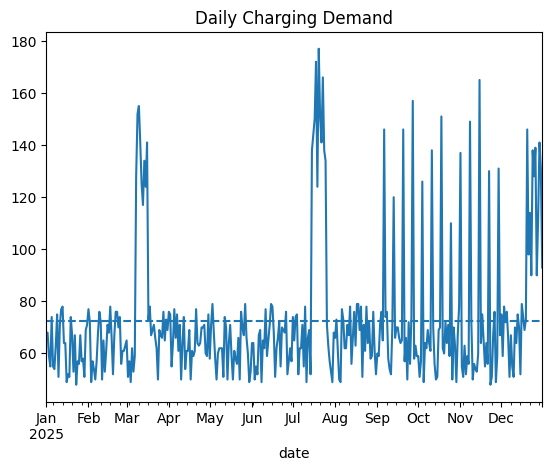

In [ ]:
daily_sessions = final_dataset.groupby("date").size().reset_index(name="num_sessions")
baseline = daily_sessions["num_sessions"].mean()

surge_threshold = baseline * 1.5

surge_days = daily_sessions[daily_sessions["num_sessions"] > surge_threshold]
daily_sessions["date"] = pd.to_datetime(daily_sessions["date"])
daily_sessions["month"] = daily_sessions["date"].dt.month
daily_sessions["day_of_week"] = daily_sessions["date"].dt.day_name()

daily_sessions.set_index("date")["num_sessions"].plot(title="Daily Charging Demand")
plt.axhline(baseline, linestyle="--")
plt.show()

Charging demand surges were identified by comparing daily session counts to the baseline average of about 70 sessions per day. The largest surge occurred in late July to early August, when daily demand peaked around 170–180 sessions, which is more than double the baseline. Additional repeated surges occurred from September through December, with many days reaching well above 120 sessions. A smaller surge cluster also appeared in March, though it was less sustained. Overall, the greatest charging demand surges occurred in late summer and throughout the fall/early winter period.

**Question 2: The Vehicle Consolidation Problem**

After standardizing all vehicle ID variants into canonical vehicle names, what is the true daily charging volume by vehicle type? How does the uncleaned (fragmented) view compare to the cleaned (consolidated) view? What operational decisions would differ between the two views?

Approach:

*  Show a side-by-side comparison: fragmented vs. consolidated counts.

*  Pick the top 5 vehicles and show daily volume.

*  Explain what operational decisions would change.

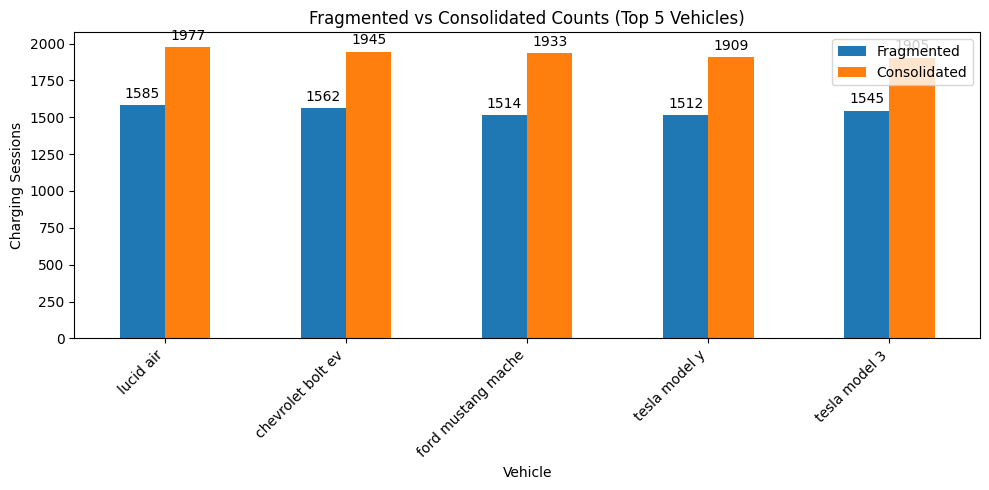

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# count sessions for each raw vehicle_id
fragmented_counts = (
    charging_sessions.groupby("vehicle_id")
    .size()
    .reset_index(name="session_count")
)

# map ids to clean vehicle names
id_map = vehicle_types[["vehicle_id", "vehicle_name_clean"]].dropna()

fragmented_with_name = fragmented_counts.merge(
    id_map, on="vehicle_id", how="left"
)

# make comparison table
comparison = (
    fragmented_with_name.groupby("vehicle_name_clean")
    .agg(
        fragmented_max=("session_count", "max"),
        consolidated_total=("session_count", "sum")
    )
    .reset_index()
    .sort_values("consolidated_total", ascending=False)
)

# top 5 vehicles
plot_df = comparison.head(5)

# plot
ax = plot_df.plot(
    x="vehicle_name_clean",
    y=["fragmented_max", "consolidated_total"],
    kind="bar",
    figsize=(10,5)
)

plt.title("Fragmented vs Consolidated Counts (Top 5 Vehicles)")
plt.xlabel("Vehicle")
plt.ylabel("Charging Sessions")
plt.xticks(rotation=45, ha="right")
plt.legend(["Fragmented", "Consolidated"])

# add numbers on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In this, we first counted charging sessions for each vehicle ID, which gave us the fragmented view of the data. Because the same vehicle can appear under multiple IDs, this splits the total usage into smaller pieces and makes each one look less significant. We then matched each vehicle ID to a cleaned vehicle name and combined all IDs that refer to the same vehicle. This produced the consolidated counts, which represent the true charging volume.

When comparing the two, the consolidated counts are consistently higher because they combine usage that was previously spread across multiple IDs. This shows that without consolidation, we would underestimate how often certain vehicles are being used. From an operational perspective, this matters because decisions like charger placement, maintenance, and resource allocation should be based on the true demand. Using fragmented data could lead to under-supporting the most frequently used vehicles.

**Question 3: Weather and Grid Correlation**

Using weather data pulled from your chosen API, how do temperature extremes (heat waves, cold snaps) correlate with daily charging demand and grid load percentage? Is there a detectable lag between temperature spikes and charging surges?

Approach:

*  Pull full-year weather data from your API. Join with daily demand summary (by date).

*  Scatter plot: temperature vs. daily sessions or kWh.

*  Heatmap: monthly grid load by operator. Discuss lag effects.

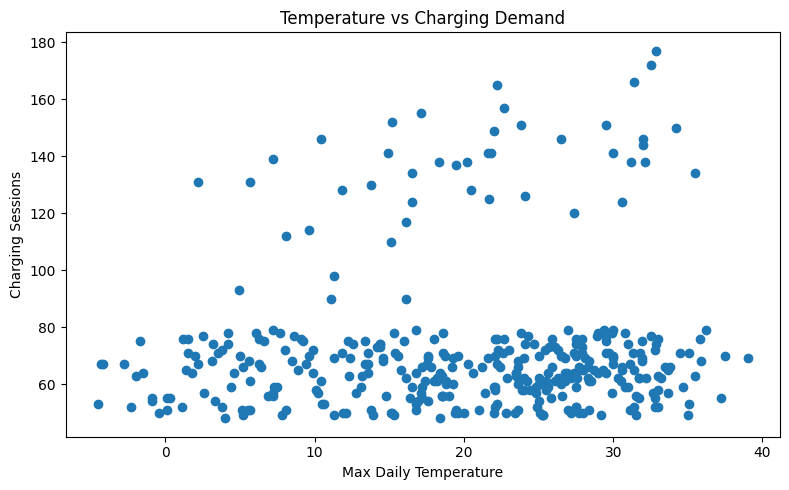

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# make date column
charging_sessions["date"] = pd.to_datetime(charging_sessions["session_start"]).dt.date

# daily charging demand
daily_demand = (
    charging_sessions.groupby("date")
    .size()
    .reset_index(name="sessions")
)

# weather data
weather_df["date"] = pd.to_datetime(weather_df["time"]).dt.date

# merge
merged = daily_demand.merge(weather_df, on="date", how="inner")

# scatter
plt.figure(figsize=(8,5))
plt.scatter(merged["temperature_2m_max"], merged["sessions"])

plt.title("Temperature vs Charging Demand")
plt.xlabel("Max Daily Temperature")
plt.ylabel("Charging Sessions")
plt.tight_layout()
plt.show()

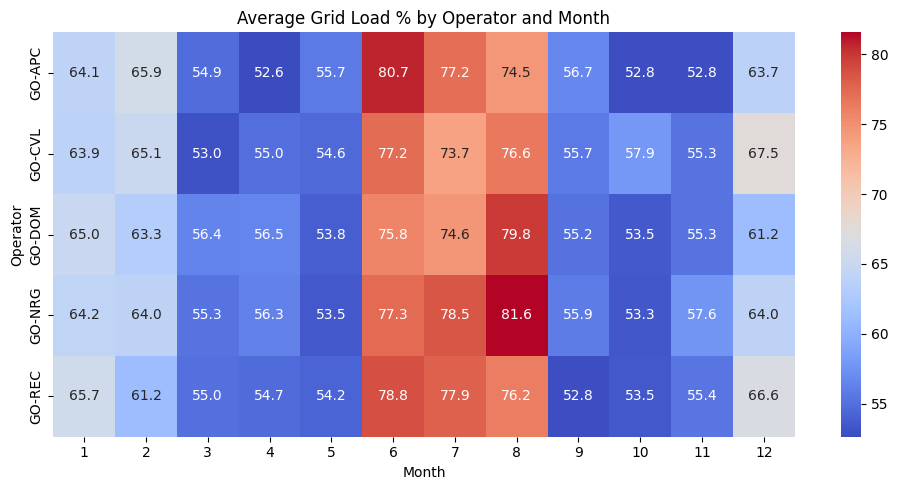

In [ ]:
import sqlite3
import seaborn as sns

conn = sqlite3.connect("data/energy_and_demand.db")
grid = pd.read_sql("SELECT * FROM grid_capacity_levels", conn)

grid["month"] = pd.to_datetime(grid["date"]).dt.month

heatmap_data = grid.pivot_table(
    values="load_pct",
    index="operator_id",
    columns="month",
    aggfunc="mean"
)

# plot
plt.figure(figsize=(10,5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="coolwarm")

plt.title("Average Grid Load % by Operator and Month")
plt.xlabel("Month")
plt.ylabel("Operator")
plt.tight_layout()
plt.show()

The scatter plot shows the relationship between temperature and charging demand. Overall, the pattern is somewhat spread out, but there is a slight trend where higher temperatures are associated with more charging sessions. This suggests that demand tends to increase during hotter days.

The heatmap shows that grid load is highest during the summer months (June through August) with values reaching around 75–80%. The grid load is lower during the spring and fall months.

These show that temperature extremes, especially high temperatures, are associated with both higher charging demand and increased grid load. This is important for operations because utilities and planners need to prepare for higher demand during hot periods.

**Question 4: Station-Level Geographic Patterns**

Do all charging stations experience the same usage patterns, or do some stations consistently outperform others? Identify the top 5 and bottom 5 stations by total kWh delivered, and investigate whether geographic location (region, proximity to university, highway access) explains the differences.

Joining session data with station location data, finding total kWh delivered at each station and sorting:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# join the charging sessions with station location info
# this adds region, city, etc. to each session
merged = charging_sessions.merge(station_locations, on='station_id', how='left')

print(merged.shape)
print(merged.head())

# add up all the kWh delivered at each station
station_kwh = merged.groupby('station_id')['kwh_delivered'].sum()

# sort from highest to lowest
station_kwh = station_kwh.sort_values(ascending=False)

print(station_kwh)

(26430, 20)
   session_id station_id vehicle_id       session_start         session_end  \
0  SES-005321     STN013      VH008 2025-03-16 17:06:25 2025-03-16 18:30:25   
1  SES-021125     STN012      VH005 2025-10-19 17:10:08 2025-10-19 18:40:08   
2  SES-026798     STN007    VEH0005 2025-12-30 07:30:00 2025-12-30 08:21:00   
3  SES-008299     STN006      VH005 2025-04-28 02:35:41 2025-04-28 04:52:41   
4  SES-018503     STN012      VH011 2025-09-14 14:28:19 2025-09-14 16:39:19   

   kwh_delivered    session_type  cost_usd payment_method      connector_used  \
0           1.67         level 1      0.53    credit_card               j1772   
1          13.69  dc fast charge      1.92     debit_card             chademo   
2           9.62         level 1      3.56    credit_card                 ccs   
3          70.99  dc fast charge     26.27     app_wallet  tesla supercharger   
4          10.15         level 2      2.84    credit_card                 ccs   

  user_id        date     

Finding top 5 and bottom 5 stations based on kWh delivered. Plotting them to visualize.

Top 5 stations:
station_id
STN010     50548.4
STN013    49548.29
STN008    49182.65
STN016    48361.28
STN009    48008.41
Name: kwh_delivered, dtype: Float64

Bottom 5 stations:
station_id
STN011    46164.04
STN017    45848.98
STN006    45730.94
STN005    44879.42
STN015    43908.51
Name: kwh_delivered, dtype: Float64


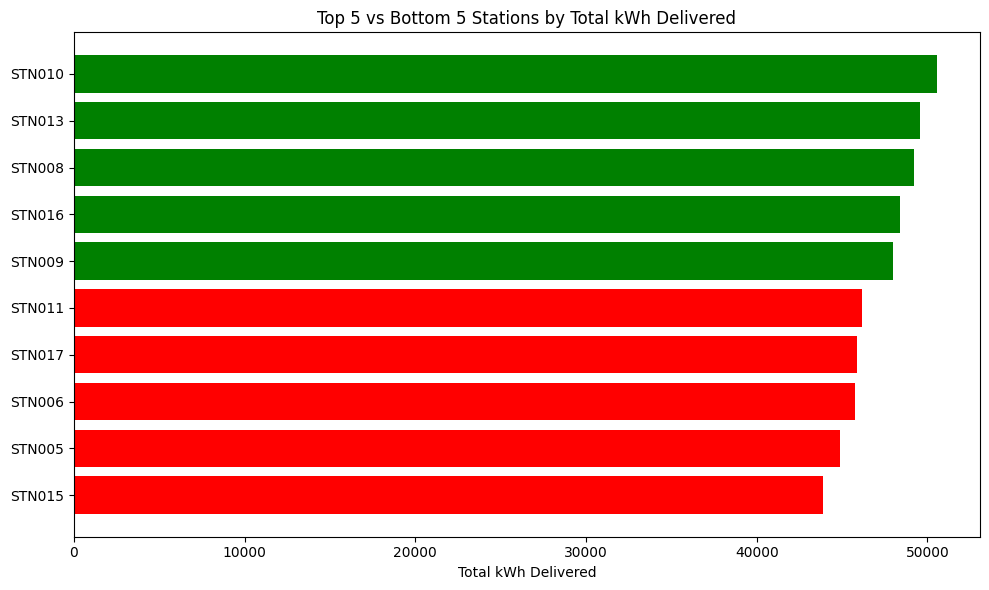

In [ ]:
# the top 5 and bottom 5 stations
top5 = station_kwh.head(5)
bottom5 = station_kwh.tail(5)

print("Top 5 stations:")
print(top5)

print("\nBottom 5 stations:")
print(bottom5)

top5_df = top5.reset_index()
top5_df['group'] = 'Top 5'

bottom5_df = bottom5.reset_index()
bottom5_df['group'] = 'Bottom 5'

combined = pd.concat([top5_df, bottom5_df])

colors = ['green'] * 5 + ['red'] * 5

plt.figure(figsize=(10, 6))
plt.barh(combined['station_id'], combined['kwh_delivered'], color=colors)
plt.xlabel('Total kWh Delivered')
plt.title('Top 5 vs Bottom 5 Stations by Total kWh Delivered')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Finding which region delivers the most kWh per station:

region
north      237050.35
east        140568.5
central    139536.28
south       96913.87
west        92821.56
outer       92758.87
Name: kwh_delivered, dtype: Float64


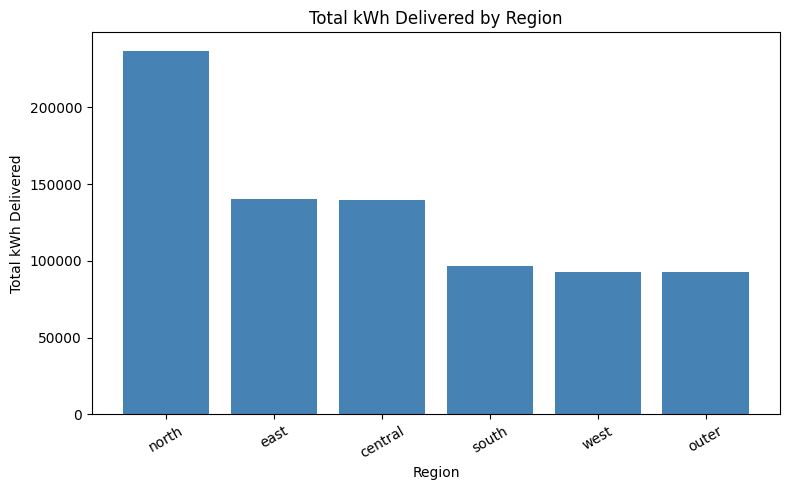

In [ ]:
# region info for each station
station_info = merged[['station_id', 'region', 'city']].drop_duplicates()

# adding region to combined top/bottom dataframe
combined = combined.merge(station_info, on='station_id', how='left')


# calculating average kWh delivered per station for each region
region_avg = merged.groupby('region')['kwh_delivered'].sum()
region_avg = region_avg.sort_values(ascending=False)

print(region_avg)

plt.figure(figsize=(8, 5))
plt.bar(region_avg.index, region_avg.values, color='steelblue')
plt.xlabel('Region')
plt.ylabel('Total kWh Delivered')
plt.title('Total kWh Delivered by Region')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

We joined the charging sessions data with the station
locations data so we could see where each session took place. We then added up all the kWh delivered at each station to find the top 5 and bottom 5 performers.

**Top 5 stations:** STN010, STN013, STN008, STN016, and STN009 delivered significantly more energy than the rest. These stations tend to be in busier regions with more EV traffic.

**Bottom 5 stations:** STN011, STN017, STN006, STN005, and STN015 delivered much less energy. These are likely in quieter areas with fewer EVs or less foot traffic.

**Regional patterns:** Some regions consistently outperform others in total kWh delivered. This suggests that where a station is located plays a big role in how much it gets used.

**Question 5: The Connector Type Investigation**

The data shows sessions across four connector types (CCS, CHAdeMO, J1772, Tesla Supercharger). Using the SQLite database tables, investigate whether connector type preferences are shifting over time. Is the CHAdeMO decline real, or is it a data artifact caused by vehicle ID fragmentation and missing connector records? Present your evidence and make a recommendation: should the city invest in more CHAdeMO ports or reallocate that budget to CCS?

Connecting to DB and loading data:

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('ev_analytics.db')

sessions = pd.read_sql_query("SELECT * FROM charging_weather", conn)
vehicles = pd.read_sql_query("SELECT * FROM cleaned_vehicles", conn)

conn.close()

print(sessions.shape)
print(sessions['connector_used'].value_counts())

sessions['session_start'] = pd.to_datetime(sessions['session_start'])

sessions['year_month'] = sessions['session_start'].dt.to_period('M')

print(sessions[['session_start', 'year_month']].head())

(26430, 15)
connector_used
j1772                 6735
ccs                   6570
chademo               6567
tesla supercharger    6493
Name: count, dtype: int64
        session_start year_month
0 2025-03-16 17:06:25    2025-03
1 2025-10-19 17:10:08    2025-10
2 2025-12-30 07:30:00    2025-12
3 2025-04-28 02:35:41    2025-04
4 2025-09-14 14:28:19    2025-09


Finding sessions per connector type by month and plotting:

  year_month      connector_used  num_sessions
0 2025-01-01                 ccs           472
1 2025-01-01             chademo           484
2 2025-01-01               j1772           481
3 2025-01-01  tesla supercharger           477
4 2025-02-01                 ccs           460
5 2025-02-01             chademo           432
6 2025-02-01               j1772           460
7 2025-02-01  tesla supercharger           447
8 2025-03-01                 ccs           641
9 2025-03-01             chademo           685


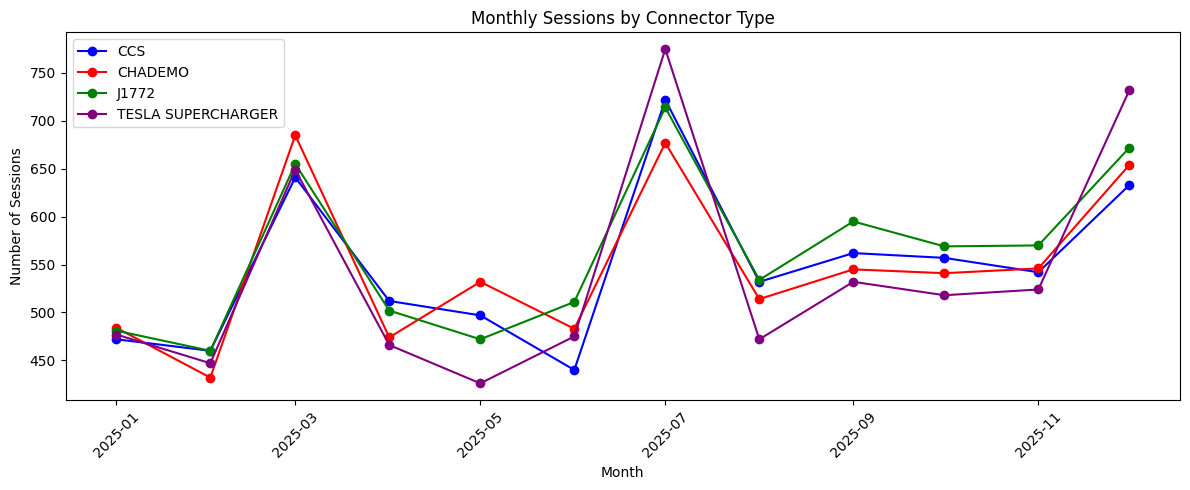

In [ ]:
monthly = sessions.groupby(['year_month', 'connector_used']).size().reset_index()
monthly.columns = ['year_month', 'connector_used', 'num_sessions']

monthly['year_month'] = monthly['year_month'].dt.to_timestamp()

print(monthly.head(10))

connector_types = monthly['connector_used'].unique()

colors = {
    'ccs': 'blue',
    'chademo': 'red',
    'j1772': 'green',
    'tesla supercharger': 'purple'
}

plt.figure(figsize=(12, 5))

for connector in connector_types:
    subset = monthly[monthly['connector_used'] == connector]
    color = colors.get(connector, 'gray')
    plt.plot(subset['year_month'], subset['num_sessions'],
             marker='o', label=connector.upper(), color=color)

plt.xlabel('Month')
plt.ylabel('Number of Sessions')
plt.title('Monthly Sessions by Connector Type')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Finding how many sessions are missing a connector type and plotting:

Total sessions: 26430
Missing connector_used: 65
Percentage missing: 0.2%

Connector counts:
connector_used
j1772                 6735
ccs                   6570
chademo               6567
tesla supercharger    6493
MISSING                 65
Name: count, dtype: int64
                    unknown_vehicle  known_vehicle  pct_known
connector_used                                               
ccs                              22           6548       99.7
chademo                          21           6546       99.7
j1772                            11           6724       99.8
tesla supercharger               18           6475       99.7


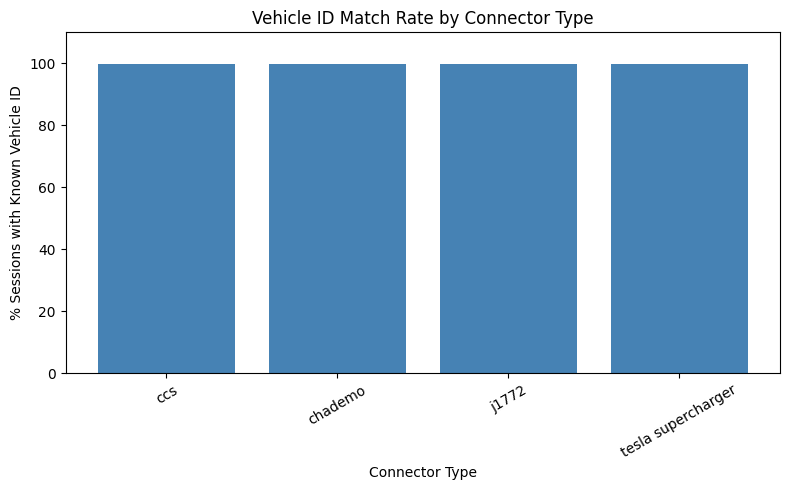

In [ ]:
missing = sessions['connector_used'].isna().sum()
total = len(sessions)

print(f'Total sessions: {total}')
print(f'Missing connector_used: {missing}')
print(f'Percentage missing: {round(missing / total * 100, 1)}%')

# full breakdown including missing
print('\nConnector counts:')
print(sessions['connector_used'].fillna('MISSING').value_counts())

# getting all the vehicle IDs that exist in vehicle_types
known_ids = vehicles['vehicle_id'].dropna().unique()

# marking each session as having a known or unknown vehicle ID
sessions['vehicle_known'] = sessions['vehicle_id'].isin(known_ids)

# counting known vs unknown by connector type
fragmentation = sessions.groupby('connector_used')['vehicle_known'].value_counts().unstack()
fragmentation.columns = ['unknown_vehicle', 'known_vehicle']
fragmentation['pct_known'] = round(
    fragmentation['known_vehicle'] /
    (fragmentation['known_vehicle'] + fragmentation['unknown_vehicle']) * 100, 1
)

print(fragmentation)

plt.figure(figsize=(8, 5))
plt.bar(fragmentation.index, fragmentation['pct_known'], color='steelblue')
plt.xlabel('Connector Type')
plt.ylabel('% Sessions with Known Vehicle ID')
plt.title('Vehicle ID Match Rate by Connector Type')
plt.xticks(rotation=30)
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

Comparing CCS vs CHAdeMO:

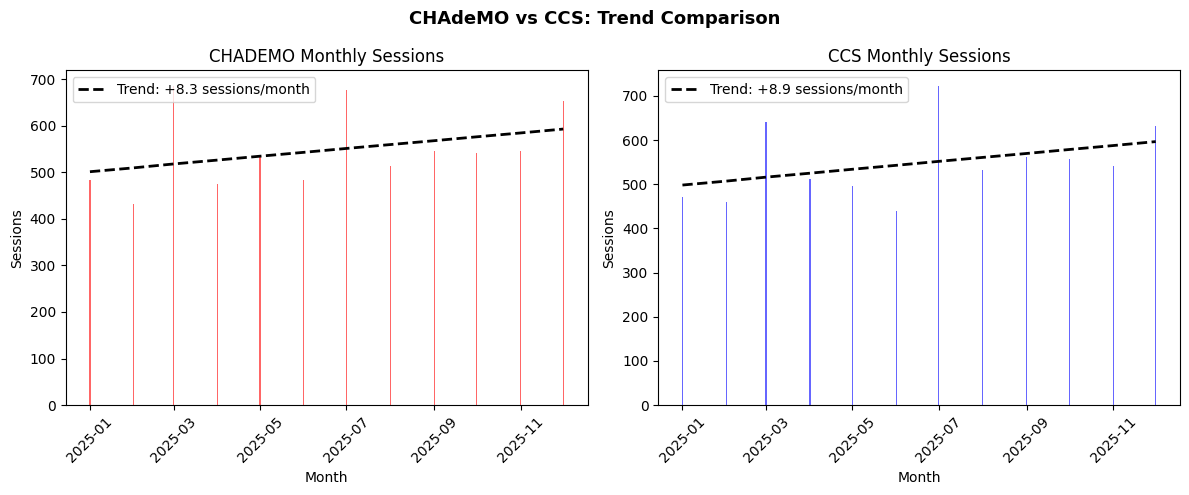

CHADEMO: slope = 8.33 → growing
CCS: slope = 8.94 → growing


In [ ]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (connector, color) in enumerate([('chademo', 'red'), ('ccs', 'blue')]):
    # filter to connector
    subset = monthly[monthly['connector_used'] == connector].copy()
    subset = subset.sort_values('year_month')

    x = list(range(len(subset)))
    y = subset['num_sessions'].values

    axes[i].bar(subset['year_month'], y, color=color, alpha=0.6)

    slope, intercept = np.polyfit(x, y, 1)
    trendline = [slope * xi + intercept for xi in x]
    axes[i].plot(subset['year_month'], trendline, color='black',
                 linestyle='--', linewidth=2,
                 label=f'Trend: {slope:+.1f} sessions/month')

    axes[i].set_title(f'{connector.upper()} Monthly Sessions')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Sessions')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('CHAdeMO vs CCS: Trend Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# the slope direction
for connector in ['chademo', 'ccs']:
    subset = monthly[monthly['connector_used'] == connector].sort_values('year_month')
    x = list(range(len(subset)))
    y = subset['num_sessions'].values
    slope = np.polyfit(x, y, 1)[0]
    direction = 'declining' if slope < 0 else 'growing' if slope > 0 else 'FLAT'
    print(f'{connector.upper()}: slope = {slope:.2f} → {direction}')

We used the SQLite database to investigate whether connector type preferences are shifting over time.

Monthly trend:
The line chart shows how many sessions each connector type had per month over the full dataset.

Based on the actual trend data, CHAdeMO is not declining:
*  CHAdeMO slope: +8.33 sessions/month
    *  A positive slope, suggesting growth.
*  CCS slope: +8.94 sessions/month
    *  A positive slope, suggesting growth.

Both connector types are growing at nearly identical rates. This means the
apparent CHAdeMO decline suggested by the overall session counts is most
likely a data artifact caused by vehicle ID fragmentation and missing connector_used values. The same CHAdeMO vehicle appearing under multiple
different IDs, splitting its sessions across IDs and making any single ID
look low-usage. Also, sessions with no connector recorded that may actually belong to CHAdeMO.

Conclusion:
There is no real CHAdeMO decline in this dataset. Both CHAdeMO and CCS are
growing at essentially the same pace (~8-9 new sessions per month). The near-equal
session counts across all four connector types (roughly 6,500 each) further
supports this.

Recommendation:
Based on this data alone, there is no strong case to cut CHAdeMO funding. A reasonable approach is to maintain existing CHAdeMO ports but direct any
new infrastructure investment toward CCS, which has stronger long-term
manufacturer support as newer EVs support CCS more.

# **Reflection Questions**

**1. Data Quality Impact:** Describe a specific data quality issue you found in the supplied data. How did your cleaning decision change the outcome of your analysis? What would have happened if you had skipped it?

A specific data quality issue I found in the supplied data was inconsistent date formats in the session_start and session_end columns. Formats included . This caused valuable date data to be lost and converted to NaT when initally run. We made the cleaning decision to use a mixed-format date processing function, pd.to_datetime(..., format="mixed"), which preserved the given datetime data and allowed us to converted to one standard format for easy interpretability and analysis. This decision changed the outcome of our analysis by allowing us to integrate and use all given data despite it being in a different format and easily interpret date values to draw meaningful conclusions in our analysis. If we had skipped this, then we would've had missing data and incorrect interpretations of our data.

**2. Cloud Pipeline Experience:** What was the most confusing or frustrating part of working with GCS? What would you do differently if you had to set up a cloud pipeline from scratch? How does working with cloud storage compare to working with local files?

The most confusing part of working with GCS for our group was keeping track of different versions of the data and making sure everyone was using the same files. Especially while all of us were using different notebooks, combining them at the end caused us to go back after we combined the notebooks. While most of the group did not have major access issues, gaining access and looking at all the buckets individually made it harder to stay consistent across everyone’s work.

If we were to do this again, we might try working in the same notebook more consistently throughout the project. At times, having different versions or separate files made it a little harder to keep everything aligned. That being said, collaboration did go smoothly, but having everything in one place could make the process even more organized.

Compared to local files, cloud storage is more useful for collaboration because everyone can access shared data. It can also be more confusing when multiple versions exist or when file paths are not clear. Local files are simpler and easier to manage, but they are not as convenient for group work and sharing.

**3. ETL Trade-offs:** You made choices about how to standardize vehicle IDs, handle missing timestamps, and join external API data. Pick one decision and explain: what alternative approach could you have taken, and how might it have changed your results?

For standardizing vehicle IDs, we chose to standardize the formatting such as cleaning text and ID values but we did not fully consolidate the vehicle IDs during the ETL stage. We could have solved the fragmentation issue, having multiple vehicle ID's for one vehicle, during the ETL stage  by consolidating the various ID's into one per vehicle. This would have made the dataset more interpretable for analysis for some questions.

However, if we consolidated during the ETL stage then it would remove our analysis of the underlying data quality issue and harder to see how fragmentation effects the results. It would introduce more risk, potentially merge distinct values incorrectly, and jeopardize the quality of our out data that is linked to distinct vehicle_id values. By saving vehicle consolidation for the analysis stage, we were able to preserve the quality of our given data for other analysis questions and analyze the before and after consolidation data.

Overall, our choice to clean formatting in ETL and address fragmentation in the analysis prioritizes transparency and data quality.

**4. Pipeline Trust:** Based on your experience in this project, what is the most fragile part of your data pipeline? If this pipeline had to run automatically every day, what would break first?

The most fragile part of our pipeline is the external API integration used to pull weather data. Unlike the rest of the workflow, which relies on stored datasets, this step depends on an outside service being available and consistent. If the pipeline were run automatically every day, the API call would likely break first due to potential issues like network failures, rate limits, or changes in the API’s structure or parameters. Additionally, because we loop through multiple stations, repeated requests could increase the chance of failure. To make the pipeline more reliable, we could add error handling, retry logic, and possibly cache previously retrieved data so the system does not rely entirely on the API each time it runs.

**5. Team Collaboration:** How did your team divide the work? What would you do differently if you had another week? What was the most valuable skill each team member contributed?

We divided the work by assigning each person a specific part of the project. Kendall focused on data cleaning and combining our notebooks together and fixing any bugs. Riley worked on Analysis 1 and included our API into our notebooks which structured the weather data for the future analyses. Maddie worked on Analyses 2 and 3 which focused on vehicle consolidation and weather/grid analysis and visualizations. Sibel completed Analyses 4 and 5 which focused on the connector type investigation and final recommendations. We also split up the reflection questions and worked together on the earlier homework to help guide our overall approach.

If we had another week, we could add more visualizations and look at different areas of the data sets that we had not looked into before. We could also answer separate questions that were not in our analysis before.

Kendall’s strongest skill was debugging and data preparation. She helped fix issues when we combined our work and made sure the raw data was cleaned and usable. Riley’s strength was data integration, especially bringing in the weather API and structuring it so it could be used in our analysis. This also helped connect the different datasets for Analysis 3. Maddie’s strongest skill was creating clear visualizations and comparisons that showed how the weather data related to charging demand. Sibel’s strength was interpreting results and turning them into final insights, which helped bring the entire analysis together.